# Building a Regression MLP Using the Sequential API

In [35]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [36]:
housing = fetch_california_housing()

In [37]:
housing.data.shape

(20640, 8)

In [38]:
housing.data

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8))

In [39]:
housing.target

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [40]:
X_train_full , X_test , y_train_full , y_test = train_test_split(housing.data , housing.target)

In [41]:
X_train , X_valid , y_train , y_valid = train_test_split(X_train_full , y_train_full)

In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)


In [43]:
X_test_scaled = scaler.transform(X_test)

In [44]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense , Flatten

In [45]:
model = Sequential()
model.add(Dense(30 , activation='relu' , input_shape=X_train.shape[1:]))
model.add(Dense(1))


D:\JUPYTER NOTEBOOK\DEEP LEARNING\dl_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
model.compile(loss = 'mean_squared_error' , optimizer='adam')
history = model.fit(X_train , y_train , epochs = 40 , validation_data = (X_valid , y_valid))

Epoch 1/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 175.2506 - val_loss: 11.6912
Epoch 2/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.4628 - val_loss: 2.9274
Epoch 3/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.4980 - val_loss: 2.0363
Epoch 4/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.0684 - val_loss: 2.8844
Epoch 5/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.3842 - val_loss: 1.1738
Epoch 6/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.3802 - val_loss: 0.8860
Epoch 7/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8992 - val_loss: 1.1237
Epoch 8/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.1890 - val_loss: 2.1194
Epoch 9/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1406 - val_loss: 0.8557
Epoch 10/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1113 - val_loss: 0.7209
Epoch 11/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.2459 - val_loss: 8.5682
Epoch 12/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/s

In [47]:
mse_test = model.evaluate(X_test , y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 873us/step - loss: 0.6993


In [48]:
X_new = X_test[:3]   

In [49]:
y_pred = model.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


In [50]:
import pandas as pd
pd.DataFrame(history.history)

,loss,val_loss
0,175.250595,11.691192
1,5.462815,2.927374
2,2.497977,2.036257
3,2.068393,2.884410
4,1.384208,1.173752
5,1.380198,0.886010
6,0.899229,1.123699
7,1.188951,2.119407
8,1.140618,0.855660
9,1.111347,0.720931


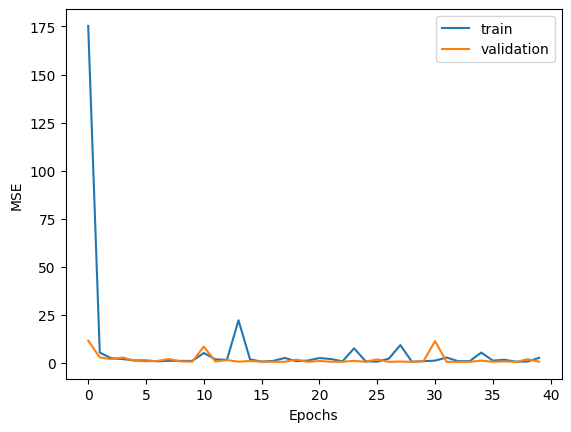

In [51]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'] , label='train')
plt.plot(history.history['val_loss'] , label = 'validation')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [52]:
test_mse = model.evaluate(X_test , y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 860us/step - loss: 0.6993


In [53]:
print("Test MSE :",test_mse)

Test MSE : 0.6993236541748047


In [54]:
y_pred = model.predict(X_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 657us/step


In [55]:
for i in range(5):
    print("Actual:", y_test[i], "Predicted:", y_pred[i][0])


Actual: 3.713 Predicted: 4.1819777
Actual: 1.486 Predicted: 1.7949383
Actual: 1.813 Predicted: 1.2391186
Actual: 0.928 Predicted: 1.8672589
Actual: 2.257 Predicted: 3.4869328


In [33]:
y_test

array([1.527, 2.313, 0.269, ..., 0.878, 1.052, 1.913], shape=(5160,))